In [57]:
from functions import *
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from numpy.lib.stride_tricks import sliding_window_view
import plotly.graph_objects as go



In [ ]:
u_data = read_pws_file("data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

# u_data = read_pws_file("data/Official_Mcy_dataset/mcy_u.faa")
# v_data = read_pws_file("data/Official_Mcy_dataset/mcy_v.faa")
# w_data = read_pws_file("data/Official_Mcy_dataset/mcy_w.faa")

dx, dy, dz = u_data['resolution_m']
ix, iy, iz = u_data['dimensions']
origin = u_data['origin_m']

x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

g = 9.81  # (m/s²)
V_a = 277.2  #
L = 1000  
dxy = dx  


In [97]:
def compute_fbar_ns(v, w, dxy, V_a, g, L):
    delta_v = np.zeros_like(v)
    half_L = L / 2  # 0.5 km
    
    num_points = int(half_L / dy)
    
    padded_v = np.pad(v, ((0, 0), (num_points, num_points), (0, 0)), mode='constant')
    
    delta_v = padded_v[:, num_points:-num_points, :] - padded_v[:, :-2*num_points, :]
    
    term1 = (V_a / (g * L)) * delta_v

    sum_w = np.sum(w[:, :num_points*2, :], axis=1)  
    term2 = (dxy / (L * V_a)) * sum_w
    term2 = np.expand_dims(term2, axis=1) 
    term2 = np.repeat(term2, term1.shape[1], axis=1)
    
    fbar_ns = term1 - term2
    
    return fbar_ns

fbar_ns = compute_fbar_ns(v_data['data'], w_data['data'], dxy, V_a, g, L)

In [98]:
def compute_fbar_ew(u, w, dxy, V_a, g, L):
    delta_u = np.zeros_like(u)
    half_L = L / 2  # 0.5 km
    
    num_points = int(half_L / dx)
    
    padded_u = np.pad(u, ((num_points, num_points), (0, 0), (0, 0)), mode='constant')
    
    delta_u = padded_u[num_points:-num_points, :, :] - padded_u[:-2*num_points, :, :]
    
    term1 = (V_a / (g * L)) * delta_u

    sum_w = np.sum(w[:num_points*2, :, :], axis=0)  
    term2 = (dxy / (L * V_a)) * sum_w
    

    fbar_ew = term1 - term2
    
    return fbar_ew

fbar_ew = compute_fbar_ew(u_data['data'], w_data['data'], dxy, V_a, g, L)

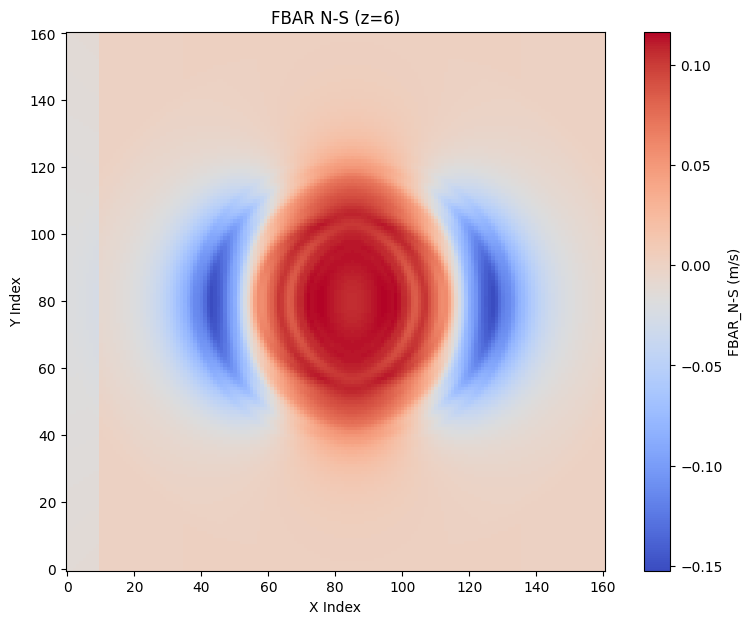

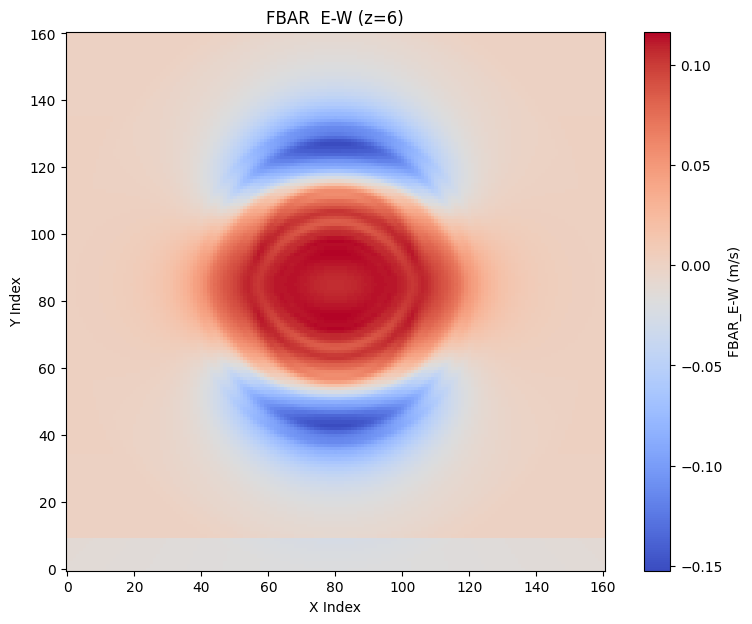

In [99]:
z_slice = 6
y_slice = 80
plt.figure(figsize=(10, 7))
plt.imshow(fbar_ns[:, :, z_slice], cmap='coolwarm', origin='lower')
plt.colorbar(label='FBAR_N-S (m/s)')
plt.title(f'FBAR N-S (z={z_slice})')
plt.xlabel('X Index')
plt.ylabel('Y Index')
plt.show()

plt.figure(figsize=(10, 7))
plt.imshow(fbar_ew[:, :, z_slice], cmap='coolwarm', origin='lower')
plt.colorbar(label='FBAR_E-W (m/s)')
plt.title(f'FBAR  E-W (z={z_slice})')
plt.xlabel('X Index')
plt.ylabel('Y Index')
plt.show()

In [90]:
data_3d = u_data['data']  


data_slice = data_3d[:, :, z_slice]

x = np.arange(data_slice.shape[0]) *50 
y = np.arange(data_slice.shape[1])  *50
X, Y = np.meshgrid(x, y, indexing='ij')

fig = go.Figure()

fig.add_trace(go.Heatmap(
    x=x,
    y=y,
    z=data_slice,
    colorscale='Viridis',
    hovertemplate='X: %{x}<br>Y: %{y}<br>Скорость: %{z} м/с',
))

fig.update_layout(
    xaxis_title="Координата X",
    yaxis_title="Координата Y",
    template="plotly_white",
    width=1200,
    height=1200
)

fig.show()

In [ ]:
u_data = read_pws_file("data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("data/111/PWS_NASA_Dataset111_w.faa")
# u_data = read_pws_file("data/Official_Mcy_dataset/mcy_u.faa")
# v_data = read_pws_file("data/Official_Mcy_dataset/mcy_v.faa")
# w_data = read_pws_file("data/Official_Mcy_dataset/mcy_w.faa")
ix, iy, iz = u_data['dimensions']
xstart, ystart, zstart = u_data['origin_m']
dx, dy, dz = u_data['resolution_m']

#сетки координат
x = np.arange(xstart, xstart + ix * dx, dx)
y = np.arange(ystart, ystart + iy * dy, dy)
z = np.arange(zstart, zstart + iz * dz, dz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Заданная точка
x0, y0, z0 = 0, 0, 0 

# Вычисление разностей координат
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0

distance = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

distance[distance == 0] = 1e-10

# Расчет радиальной скорости
U = u_data['data']
V = v_data['data']
W = w_data['data']
radial_velocity = (U * delta_x + V * delta_y + W * delta_z) / distance
wind_speed = np.sqrt(U**2 + V**2 + W**2)  
f_factor = radial_velocity / wind_speed # F = Vрадиальная / |Vветра|
f_factor = np.nan_to_num(f_factor, nan=0.0)  
f_factor = f_factor*(-1)



/tmp/ipykernel_33955/1408858177.py:35: RuntimeWarning:

invalid value encountered in divide



In [63]:
x = np.linspace(xstart, xstart + (ix-1)*dx, ix)
y = np.linspace(ystart, ystart + (iy-1)*dy, iy)
z = np.linspace(zstart, zstart + (iz-1)*dz, iz)
X_plt, Y_plt, Z_plt = np.meshgrid(x, y, z, indexing='ij')

step = 5
X_sparse = X_plt[::step, ::step, ::step]
Y_sparse = Y_plt[::step, ::step, ::step]
Z_sparse = Z_plt[::step, ::step, ::step]
f_factor_sparse = f_factor[::step, ::step, ::step]

hover_text = [
    f'X: {x}, Y: {y}, Z: {z}, F-factor: {f:.5f}'
    for x, y, z, f in zip(X_sparse.flatten(), Y_sparse.flatten(), Z_sparse.flatten(), f_factor_sparse.flatten())
]

fig = go.Figure(data=[
    go.Scatter3d(
        x=X_sparse.flatten(),
        y=Y_sparse.flatten(),
        z=Z_sparse.flatten(),
        mode='markers',
        marker=dict(
            size=8,
            color=f_factor_sparse.flatten(),
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title="F-factor")
        ),
        text=hover_text,  
        hoverinfo='text' 
    )
])

fig.update_layout(
    title="3D Распределение F-фактора",
    scene=dict(
        xaxis_title='X (м)',
        yaxis_title='Y (м)',
        zaxis_title='Z (м)',
        aspectmode='data'
    ),
    margin=dict(r=0, l=0, b=0, t=30),
    width=1200,
    height=800
)

fig.show()